In [212]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [213]:
df = pd.read_csv("../data/Carbon_Emission.csv")
df.head()

,Body Type,Sex,Diet,How Often Shower,Heating Energy Source,Transport,Vehicle Type,Social Activity,Monthly Grocery Bill,Frequency of Traveling by Air,Vehicle Monthly Distance Km,Waste Bag Size,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,Energy efficiency,Recycling,Cooking_With,CarbonEmission
0,overweight,female,pescatarian,daily,coal,public,NaN,often,230,frequently,210,large,4,7,26,1,No,['Metal'],"['Stove', 'Oven']",2238
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,NaN,often,114,rarely,9,extra large,3,9,38,5,No,['Metal'],"['Stove', 'Microwave']",1892
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,2472,small,1,14,47,6,Sometimes,['Metal'],"['Oven', 'Microwave']",2595
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,NaN,sometimes,157,rarely,74,medium,3,20,5,7,Sometimes,"['Paper', 'Plastic', 'Glass', 'Metal']","['Microwave', 'Grill', 'Airfryer']",1074
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,8457,large,1,3,5,6,Yes,['Paper'],['Oven'],4743


In [214]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")

In [215]:
features = [
    "Body_Type",
    "Sex",
    "Diet",
    "How_Often_Shower",
    "Heating_Energy_Source",
    "Transport",
    "Social_Activity",
    "Frequency_of_Traveling_by_Air",
    "Waste_Bag_Size",
    "Energy_efficiency",
    "Monthly_Grocery_Bill",
    "Vehicle_Monthly_Distance_Km",
    "Waste_Bag_Weekly_Count",
    "How_Long_TV_PC_Daily_Hour",
    "How_Long_Internet_Daily_Hour",
    "How_Many_New_Clothes_Monthly"
]

target = "CarbonEmission"

In [216]:
df.head()
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Body_Type                      10000 non-null  str  
 1   Sex                            10000 non-null  str  
 2   Diet                           10000 non-null  str  
 3   How_Often_Shower               10000 non-null  str  
 4   Heating_Energy_Source          10000 non-null  str  
 5   Transport                      10000 non-null  str  
 6   Vehicle_Type                   3279 non-null   str  
 7   Social_Activity                10000 non-null  str  
 8   Monthly_Grocery_Bill           10000 non-null  int64
 9   Frequency_of_Traveling_by_Air  10000 non-null  str  
 10  Vehicle_Monthly_Distance_Km    10000 non-null  int64
 11  Waste_Bag_Size                 10000 non-null  str  
 12  Waste_Bag_Weekly_Count         10000 non-null  int64
 13  How_Long_TV_PC_Daily_Hour   

(10000, 20)

In [217]:
df.columns = df.columns.str.strip()

In [218]:
df.isnull().sum()

Body_Type                           0
Sex                                 0
Diet                                0
How_Often_Shower                    0
Heating_Energy_Source               0
Transport                           0
Vehicle_Type                     6721
Social_Activity                     0
Monthly_Grocery_Bill                0
Frequency_of_Traveling_by_Air       0
Vehicle_Monthly_Distance_Km         0
Waste_Bag_Size                      0
Waste_Bag_Weekly_Count              0
How_Long_TV_PC_Daily_Hour           0
How_Many_New_Clothes_Monthly        0
How_Long_Internet_Daily_Hour        0
Energy_efficiency                   0
Recycling                           0
Cooking_With                        0
CarbonEmission                      0
dtype: int64

In [219]:
df["CarbonEmission"].describe()

count    10000.000000
mean      2269.147300
std       1017.675247
min        306.000000
25%       1538.000000
50%       2080.000000
75%       2768.000000
max       8377.000000
Name: CarbonEmission, dtype: float64

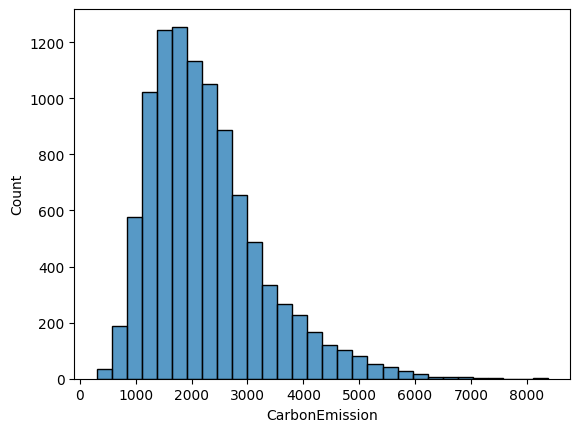

In [220]:
sns.histplot(df["CarbonEmission"], bins=30)
plt.show()

In [221]:
cat_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

In [222]:
cat_cols

Index(['Body_Type', 'Sex', 'Diet', 'How_Often_Shower', 'Heating_Energy_Source',
       'Transport', 'Vehicle_Type', 'Social_Activity',
       'Frequency_of_Traveling_by_Air', 'Waste_Bag_Size', 'Energy_efficiency',
       'Recycling', 'Cooking_With'],
      dtype='str')

In [223]:
num_cols

Index(['Monthly_Grocery_Bill', 'Vehicle_Monthly_Distance_Km',
       'Waste_Bag_Weekly_Count', 'How_Long_TV_PC_Daily_Hour',
       'How_Many_New_Clothes_Monthly', 'How_Long_Internet_Daily_Hour',
       'CarbonEmission'],
      dtype='str')

In [224]:
for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts().head())


 Body_Type
Body_Type
underweight    2540
obese          2500
overweight     2487
normal         2473
Name: count, dtype: int64

 Sex
Sex
female    5007
male      4993
Name: count, dtype: int64

 Diet
Diet
pescatarian    2554
vegan          2497
omnivore       2492
vegetarian     2457
Name: count, dtype: int64

 How_Often_Shower
How_Often_Shower
daily              2546
twice a day        2516
less frequently    2487
more frequently    2451
Name: count, dtype: int64

 Heating_Energy_Source
Heating_Energy_Source
electricity    2552
coal           2523
wood           2463
natural gas    2462
Name: count, dtype: int64

 Transport
Transport
walk/bicycle    3427
public          3294
private         3279
Name: count, dtype: int64

 Vehicle_Type
Vehicle_Type
lpg         697
electric    671
petrol      647
hybrid      642
diesel      622
Name: count, dtype: int64

 Social_Activity
Social_Activity
never        3406
often        3319
sometimes    3275
Name: count, dtype: int64

 Frequency_of_Trav

In [225]:
df[num_cols].describe()

,Monthly_Grocery_Bill,Vehicle_Monthly_Distance_Km,Waste_Bag_Weekly_Count,How_Long_TV_PC_Daily_Hour,How_Many_New_Clothes_Monthly,How_Long_Internet_Daily_Hour,CarbonEmission
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,173.875200,2031.485900,4.024600,12.139200,25.109000,11.889100,2269.147300
std,72.234018,2769.715597,1.990375,7.106369,14.698725,7.277218,1017.675247
min,50.000000,0.000000,1.000000,0.000000,0.000000,0.000000,306.000000
25%,111.000000,69.000000,2.000000,6.000000,13.000000,6.000000,1538.000000
50%,173.000000,823.000000,4.000000,12.000000,25.000000,12.000000,2080.000000
75%,237.000000,2516.750000,6.000000,18.000000,38.000000,18.000000,2768.000000
max,299.000000,9999.000000,7.000000,24.000000,50.000000,24.000000,8377.000000


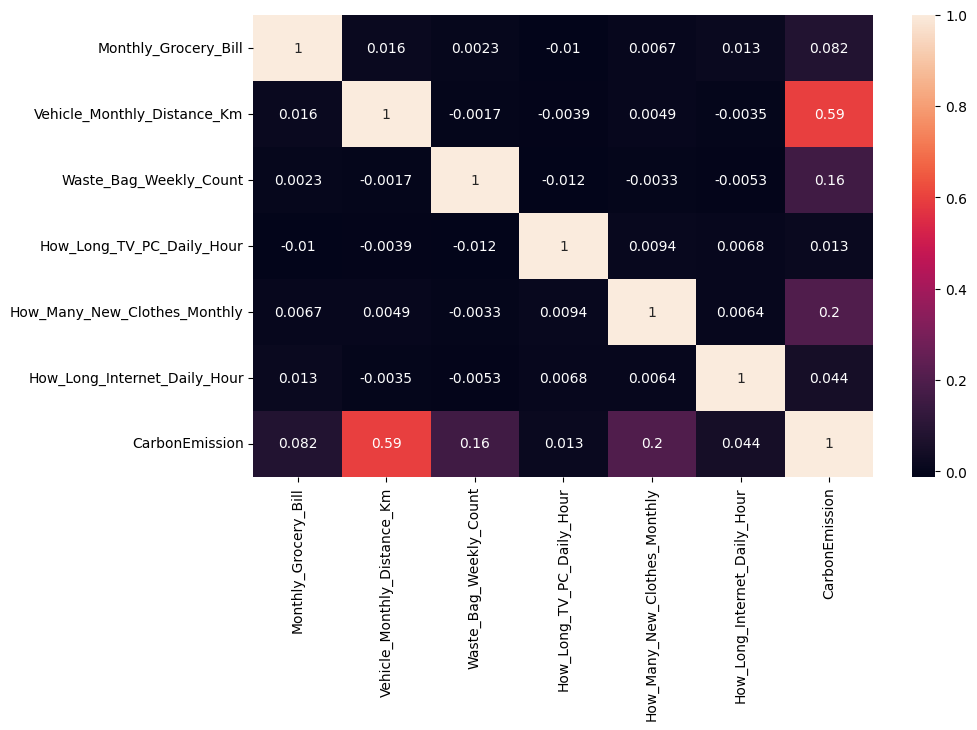

In [226]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True)
plt.show()

In [227]:
df.groupby("Transport")["CarbonEmission"].mean().sort_values()

Transport
walk/bicycle    1879.738547
public          1965.789314
private         2980.878012
Name: CarbonEmission, dtype: float64

In [228]:
df.groupby("Diet")["CarbonEmission"].mean().sort_values()

Diet
vegan          2215.761314
vegetarian     2216.814408
pescatarian    2251.835552
omnivore       2391.980738
Name: CarbonEmission, dtype: float64

In [229]:
df.groupby("Heating_Energy_Source")["CarbonEmission"].mean().sort_values()

Heating_Energy_Source
electricity    2039.379702
natural gas    2248.124289
wood           2296.815672
coal           2495.060246
Name: CarbonEmission, dtype: float64

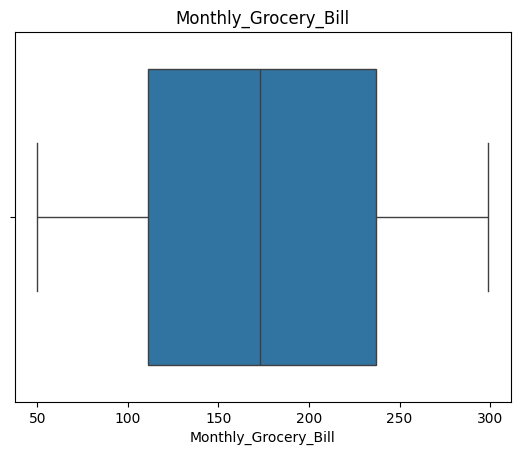

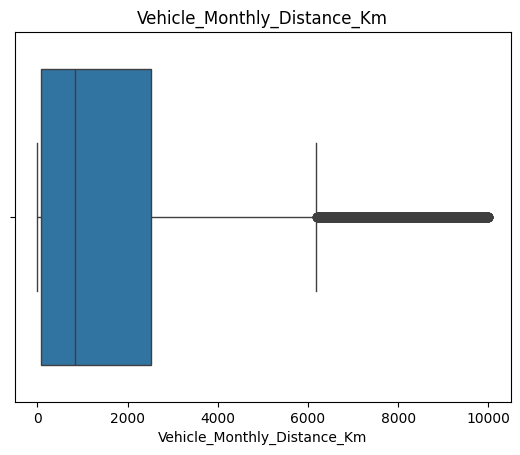

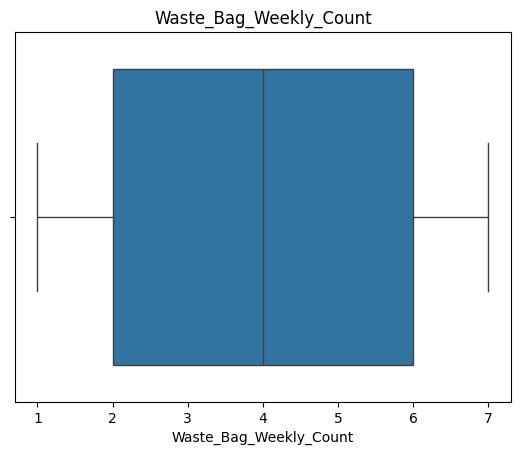

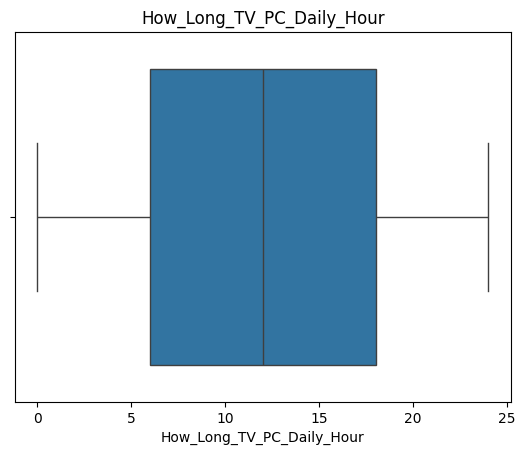

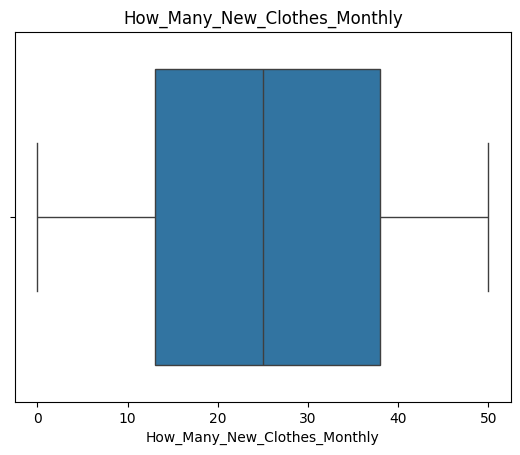

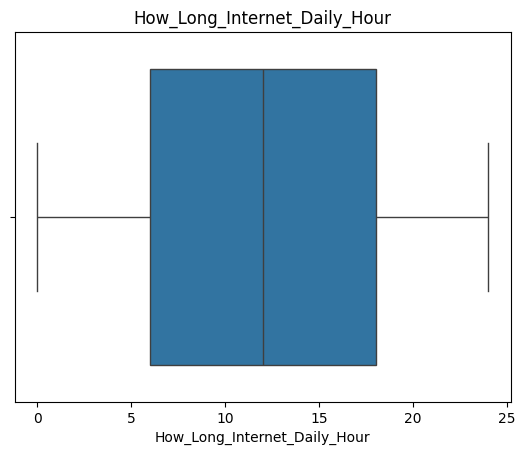

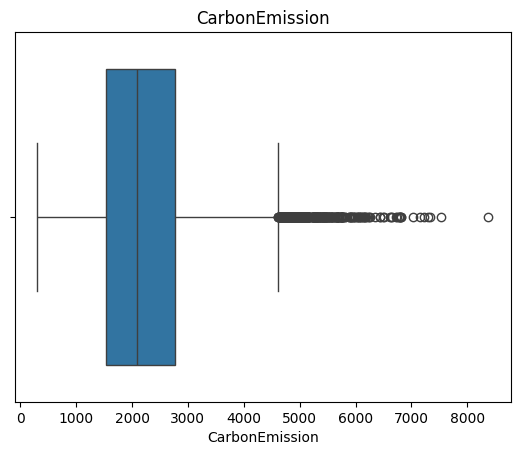

In [230]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [231]:
df["Recycling"].head()
df["Cooking_With"].head()

0                     ['Stove', 'Oven']
1                ['Stove', 'Microwave']
2                 ['Oven', 'Microwave']
3    ['Microwave', 'Grill', 'Airfryer']
4                              ['Oven']
Name: Cooking_With, dtype: str

In [232]:
import ast

df["Recycling"] = df["Recycling"].apply(lambda x: ",".join(ast.literal_eval(x)) if isinstance(x, str) else x)
df["Cooking_With"] = df["Cooking_With"].apply(lambda x: ",".join(ast.literal_eval(x)) if isinstance(x, str) else x)